# MCA - Multiple Correspondence Analysis : detect profiles in the population



ACM : Analyse factorielle des correspondances multiples



!!! Compléter les références !!!


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import sqlite3 as sql

In [35]:
from fanalysis.ca import CA 
from fanalysis.mca import MCA

In [36]:
### Importer un module de fonctions crées ad hoc
##  ATTENTION : le fichier 'sparql_functions.py' doit se trouver 
#   dans un dossier qui se situe dans le chemin ('path') de recherche
#   vu par le présent carnet Jupyter afin que
#   l'importation fonctionne correctement

import sys
from importlib import reload


# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')



In [37]:

import bivariate_library as bl
import correspondence_analysis_library as cal
import cluster_functions as cf


In [38]:
### Use this pnéy to reload the functions if modified
# print(reload(bl))
# print(reload(cal))  

## Import the data and prepare the analysis

In this notebook, we use the data produced with the [bivariate analysis notebook using countries](da3-1_countries_bivariate_analysis.ipynb) and the data collected in the [da5-employer.md](../../documentation/wikidata/data-analysis/da5-employer.md) and [da5-employer.sql](../../documentation/wikidata/data-analysis/da5-employer.sql) files.



In [39]:
csv_address='da_data/da4-AFC.csv'
df_p = pd.read_csv(csv_address)
df_p.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,1806,male,Prince William County,POINT (-77.48 38.7),http://www.wikidata.org/entity/Q183263,23,Northern America,US,United States,United States,USA,United States Can.,1851,1846-1870
1,http://www.wikidata.org/entity/Q1031841,Constantin Pecqueur,1801,male,Arleux,POINT (3.106389 50.280278),http://www.wikidata.org/entity/Q61573,22,Western Europe,FR,France,France,FRA,France,1846,1846-1870
2,http://www.wikidata.org/entity/Q452627,Pierre Guillaume Frédéric le Play,1806,male,La Rivière-Saint-Sauveur,POINT (0.271389 49.407222),http://www.wikidata.org/entity/Q383959,22,Western Europe,FR,France,France,FRA,France,1851,1846-1870


In [40]:
df_p = df_p.drop(['CNTR_ID', 'CNTR_NAME', 'ISO3_CODE', 'activityYear', 'uriPlace', 'FID', 'CNTR_ID'], axis=1)

In [41]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7917 entries, 0 to 7916
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   uriPer           7917 non-null   object
 1   labelPer         7917 non-null   object
 2   birthYear        7917 non-null   int64 
 3   gender           7917 non-null   object
 4   labelPlace       7917 non-null   object
 5   geometry         7917 non-null   object
 6   REGION           7917 non-null   object
 7   NAME_ENGL        7917 non-null   object
 8   coded_country    7917 non-null   object
 9   periodsActivity  7518 non-null   object
dtypes: int64(1), object(9)
memory usage: 618.6+ KB


In [42]:
df_p=df_p.rename(columns={'uriPer': 'person_uri'})

In [43]:
df_p.head(2)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity
0,http://www.wikidata.org/entity/Q5539301,George Fitzhugh,1806,male,Prince William County,POINT (-77.48 38.7),Northern America,United States,United States Can.,1846-1870
1,http://www.wikidata.org/entity/Q1031841,Constantin Pecqueur,1801,male,Arleux,POINT (3.106389 50.280278),Western Europe,France,France,1846-1870


In [44]:
pd.set_option('display.max_columns', None)
# Reset to default settings if needed later
# pd.reset_option('display.max_columns')

In [45]:
### Import the new qualitative values to be added: occupation and employer class
csv_address='da_data/da5-persons-features.csv'
# Explicitly tell pandas which strings to treat as NA (exclude 'NA' from the list)
# By default, pandas treats 'NA', 'N/A', 'NaN', etc. as missing values.
# If you want to override this by specifying a custom list that does NOT include 'NA'.
## df_pfeat = pd.read_csv(csv_address, na_values=['', 'N/A', 'NULL', 'None'])
df_pfeat = pd.read_csv(csv_address)
df_pfeat.head()

,pk_person_features,person_uri,occupation_sec1,coded_employer
0,1,http://www.wikidata.org/entity/Q1000087,university-teacher,agency
1,2,http://www.wikidata.org/entity/Q1000348,university-teacher,university
2,3,http://www.wikidata.org/entity/Q1000622,university-teacher,publisher
3,9,http://www.wikidata.org/entity/Q1002184,university-teacher,university
4,14,http://www.wikidata.org/entity/Q100273083,journalist,publisher


In [46]:
### Observe the 
df_pfeat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5986 entries, 0 to 5985
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   pk_person_features  5986 non-null   int64 
 1   person_uri          5986 non-null   object
 2   occupation_sec1     5986 non-null   object
 3   coded_employer      5986 non-null   object
dtypes: int64(1), object(3)
memory usage: 187.2+ KB


In [47]:
## Merge the two dataframes
df_pm = pd.merge(df_p,df_pfeat, on='person_uri')  
# following part was used for inspection
# , how='left')

In [48]:
## The small number depends on the considered countries
df_pm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3300 entries, 0 to 3299
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   person_uri          3300 non-null   object
 1   labelPer            3300 non-null   object
 2   birthYear           3300 non-null   int64 
 3   gender              3300 non-null   object
 4   labelPlace          3300 non-null   object
 5   geometry            3300 non-null   object
 6   REGION              3300 non-null   object
 7   NAME_ENGL           3300 non-null   object
 8   coded_country       3300 non-null   object
 9   periodsActivity     3188 non-null   object
 10  pk_person_features  3300 non-null   int64 
 11  occupation_sec1     3300 non-null   object
 12  coded_employer      3300 non-null   object
dtypes: int64(2), object(11)
memory usage: 335.3+ KB


### Manage secondary occupation

We will have to code a part of the categories because their number is too small, which makes the variable too sparse.

In [49]:
### Group and count: secondary occupation
# We observe some dispersion that requires grouping the categories of the variable
df_count = df_pm.groupby('occupation_sec1').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(len(df_count))
print(df_count.iloc[:50])



127
                              number
occupation_sec1                     
university-teacher              2245
writer                           173
politician                       112
historian                         84
political-scientist               67
researcher                        65
philosopher                       63
anthropologist                    52
economist                         49
journalist                        37
psychologist                      30
professor                         30
scientist                         28
teacher                           20
academic                          11
pedagogue                         11
criminologist                     10
translator                         7
professeur-des-universités         6
jurist                             6
educator                           6
social-scientist                   6
author                             6
literary-critic                    5
statistician                      

In [50]:
## We only take the first 19 elements in the list, the more interesting ones
ldf = df_count[df_count.number > 17].index.to_list()
print(ldf)

['university-teacher', 'writer', 'politician', 'historian', 'political-scientist', 'researcher', 'philosopher', 'anthropologist', 'economist', 'journalist', 'psychologist', 'professor', 'scientist', 'teacher']


In [51]:
## prepare the function to code the data
def code_occupation_sec1(occup, ldf):

    """
    codes values according to list
    """

    if occup in ldf:
        output = occup
    else:
        output= 'other'
    return output        

In [52]:
### Code the data
df_pm.occupation_sec1 = df_pm.occupation_sec1.apply(lambda x: code_occupation_sec1(x, ldf))

In [53]:
### Group and count: secondary occupation
# We observe the results of the codind
df_count = df_pm.groupby('occupation_sec1').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(df_count)


                     number
occupation_sec1            
university-teacher     2245
other                   245
writer                  173
politician              112
historian                84
political-scientist      67
researcher               65
philosopher              63
anthropologist           52
economist                49
journalist               37
psychologist             30
professor                30
scientist                28
teacher                  20


In [54]:
df_pm.head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_sec1,coded_employer
0,http://www.wikidata.org/entity/Q2993155,Konstantin Kavelin,1818,male,Saint Petersburg,POINT (30.316667 59.95),European Russia,Russian Federation,Russian Federation,1846-1870,11704,historian,publisher
1,http://www.wikidata.org/entity/Q555693,Timofey Granovsky,1813,male,Oryol,POINT (36.069444 52.968611),European Russia,Russian Federation,Russian Federation,1846-1870,14217,university-teacher,university
2,http://www.wikidata.org/entity/Q144535,Herbert Spencer,1820,male,Derby,POINT (-1.476667 52.921667),Northern Europe,United Kingdom,United Kingdom,1846-1870,8360,writer,other


## MCA

In [55]:
data_cat = df_pm[['gender', 'coded_country', 'occupation_sec1', 'coded_employer']]
data_cat.head(3)


,gender,coded_country,occupation_sec1,coded_employer
0,male,Russian Federation,historian,publisher
1,male,Russian Federation,university-teacher,university
2,male,United Kingdom,writer,other


In [56]:
DActives=data_cat

In [57]:
# We inspect the table that will be analysed
p = DActives.shape[1]
#nombre d'observations
n = DActives.shape[0]
print('Number of variables:', p, ' -- Nomber of individuals (rows):', n)
#codage en 0/1


Number of variables: 4  -- Nomber of individuals (rows): 3300


### Complete disjunctive table 

Sometimes also referred to as a dummy variable matrix or indicator matrix.

In the context of Multiple Correspondence Analysis (MCA), this table is used to transform qualitative (categorical) variables into a quantitative format suitable for analysis. Each category of a qualitative variable becomes a separate binary column (0 or 1), indicating the absence or presence of that category for each individual.

In [58]:
## Complete disjunctive table
X = pd.get_dummies(DActives,prefix='',prefix_sep='')*1
X.head(3)

,female,male,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Japan,Poland,Russian Federation,South America,Spain Port.,United Kingdom,United States Can.,anthropologist,economist,historian,journalist,other,philosopher,political-scientist,politician,professor,psychologist,researcher,scientist,teacher,university-teacher,writer,GLAM,academy,agency,college,education,enterprise,facility,institute,institution,newspaper,organization,other,publisher,school,university
0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [59]:
### Nombre total de modalités, toute variable confondue
M = X.shape[1]
print('Number of categories:', M)
#nombre max de facteurs
Hmax = M-p
print('Maximum number of factors:', Hmax)

Number of categories: 47
Maximum number of factors: 43


In [60]:
Xm = X.copy(deep=True)
#Total sum per row: 
Xm.loc[:,'Total'] = Xm.sum(axis=1)
#Total sum per column: 
Xm.loc['Total',:] = Xm.sum(axis=0)
Xm.tail()

,female,male,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Japan,Poland,Russian Federation,South America,Spain Port.,United Kingdom,United States Can.,anthropologist,economist,historian,journalist,other,philosopher,political-scientist,politician,professor,psychologist,researcher,scientist,teacher,university-teacher,writer,GLAM,academy,agency,college,education,enterprise,facility,institute,institution,newspaper,organization,other,publisher,school,university,Total
3296,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
3297,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0
3298,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
3299,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0
Total,661.0,2639.0,137.0,94.0,128.0,103.0,85.0,264.0,738.0,216.0,60.0,261.0,191.0,121.0,176.0,146.0,580.0,52.0,49.0,84.0,37.0,245.0,63.0,67.0,112.0,30.0,30.0,65.0,28.0,20.0,2245.0,173.0,22.0,8.0,105.0,16.0,1113.0,18.0,6.0,148.0,23.0,11.0,209.0,58.0,957.0,34.0,572.0,13200.0


## MCA

The Complete disjoint table is created interanlly by the software

In [61]:
acm = MCA(row_labels=DActives.index,var_labels=DActives.columns)
acm.fit(DActives.values)

,n_components,None
,row_labels,"RangeIndex(st...=3300, step=1)"
,var_labels,Index(['gende...type='object')
,stats,True


In [62]:
eig = pd.DataFrame(acm.eig_).transpose()
eig.columns=['contribution','freq','freq_cumulee']

print('Number of factors (approximation tables):', len(eig), '\n')
print(eig.head(), eig.tail())


Number of factors (approximation tables): 43 

   contribution      freq  freq_cumulee
0      0.405565  3.772697      3.772697
1      0.372912  3.468953      7.241650
2      0.364384  3.389616     10.631266
3      0.327516  3.046662     13.677929
4      0.315028  2.930495     16.608423     contribution      freq  freq_cumulee
38      0.181666  1.689917     94.401193
39      0.178820  1.663445     96.064637
40      0.164633  1.531467     97.596104
41      0.152020  1.414141     99.010246
42      0.106399  0.989754    100.000000


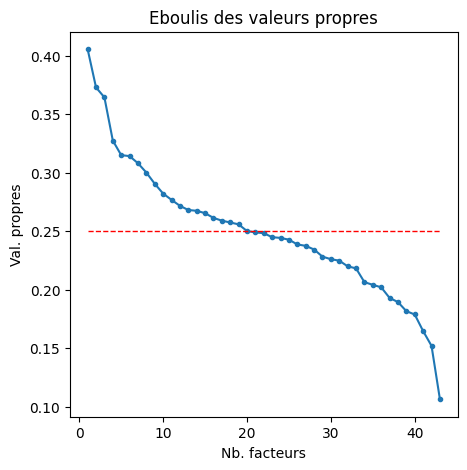

In [63]:
#éboulis des v.p.
fix,ax = plt.subplots(figsize=(5,5))
ax.plot(range(1,Hmax+1),acm.eig_[0],".-")
ax.set_xlabel("Nb. facteurs")
ax.set_ylabel("Val. propres")
plt.title("Eboulis des valeurs propres")
#seuil - Règle de Kaiser
ax.plot([1,Hmax],[1/p,1/p],"r--",linewidth=1)
plt.show()

*Diagramme d'éboulis*. Représentation graphique ayant pour but d'identifier un point d'inflexion dans une courbe de la variance. Le nom donné à ce type de graphique vient de la ressemblance de la courbe avec le profil des éboulis (scree) au bas d'une falaise. [DataFranca, Diagramme d'éboulis, 2024](https://datafranca.org/wiki/index.php?title=Diagramme_d%27%C3%A9boulis&oldid=93502)

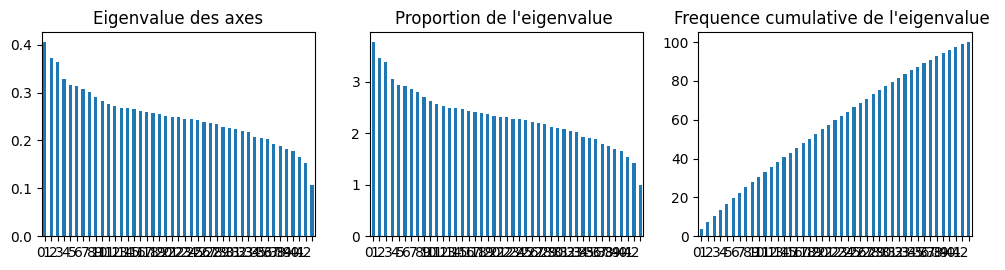

In [64]:

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12,3))

eig.iloc[:,0].plot(kind='bar', ax=axes[0], title='Eigenvalue des axes')
eig.iloc[:,1].plot(kind='bar', ax=axes[1], title="Proportion de l'eigenvalue ")
eig.iloc[:,2].plot(kind='bar', ax=axes[2], title="Frequence cumulative de l'eigenvalue ")
# Met les valeurs xticks en vertical
fig.autofmt_xdate(rotation=0)
plt.show()

<Axes: title={'center': 'Factor map for columns'}, xlabel='Dim 1 (3.77%)', ylabel='Dim 2 (3.47%)'>

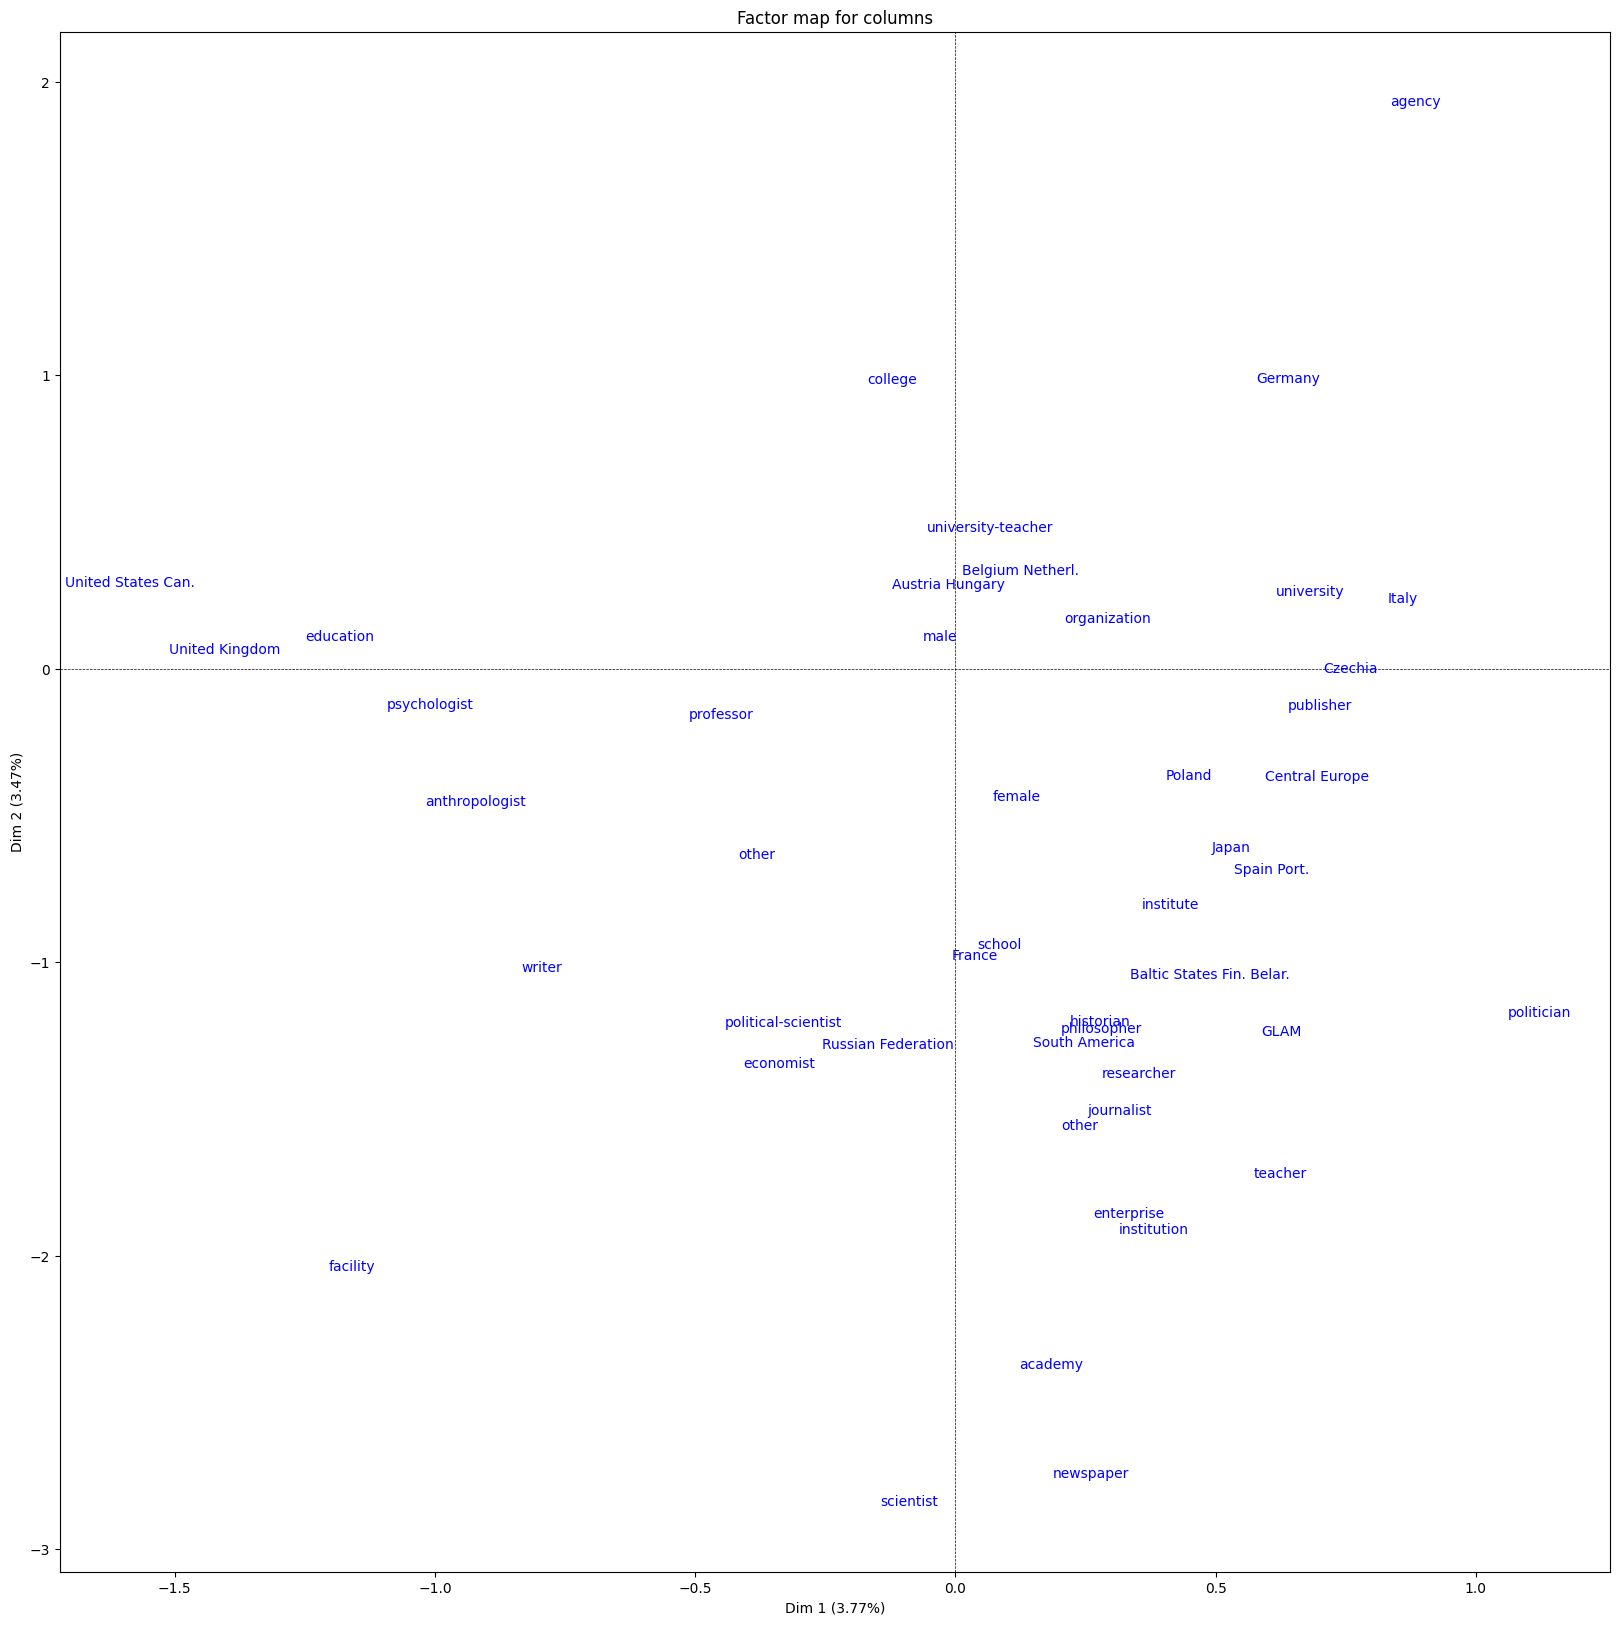

In [65]:
# Mapping des points colonnes
acm.mapping_col(num_x_axis=1, num_y_axis=2, figsize=(20,20))

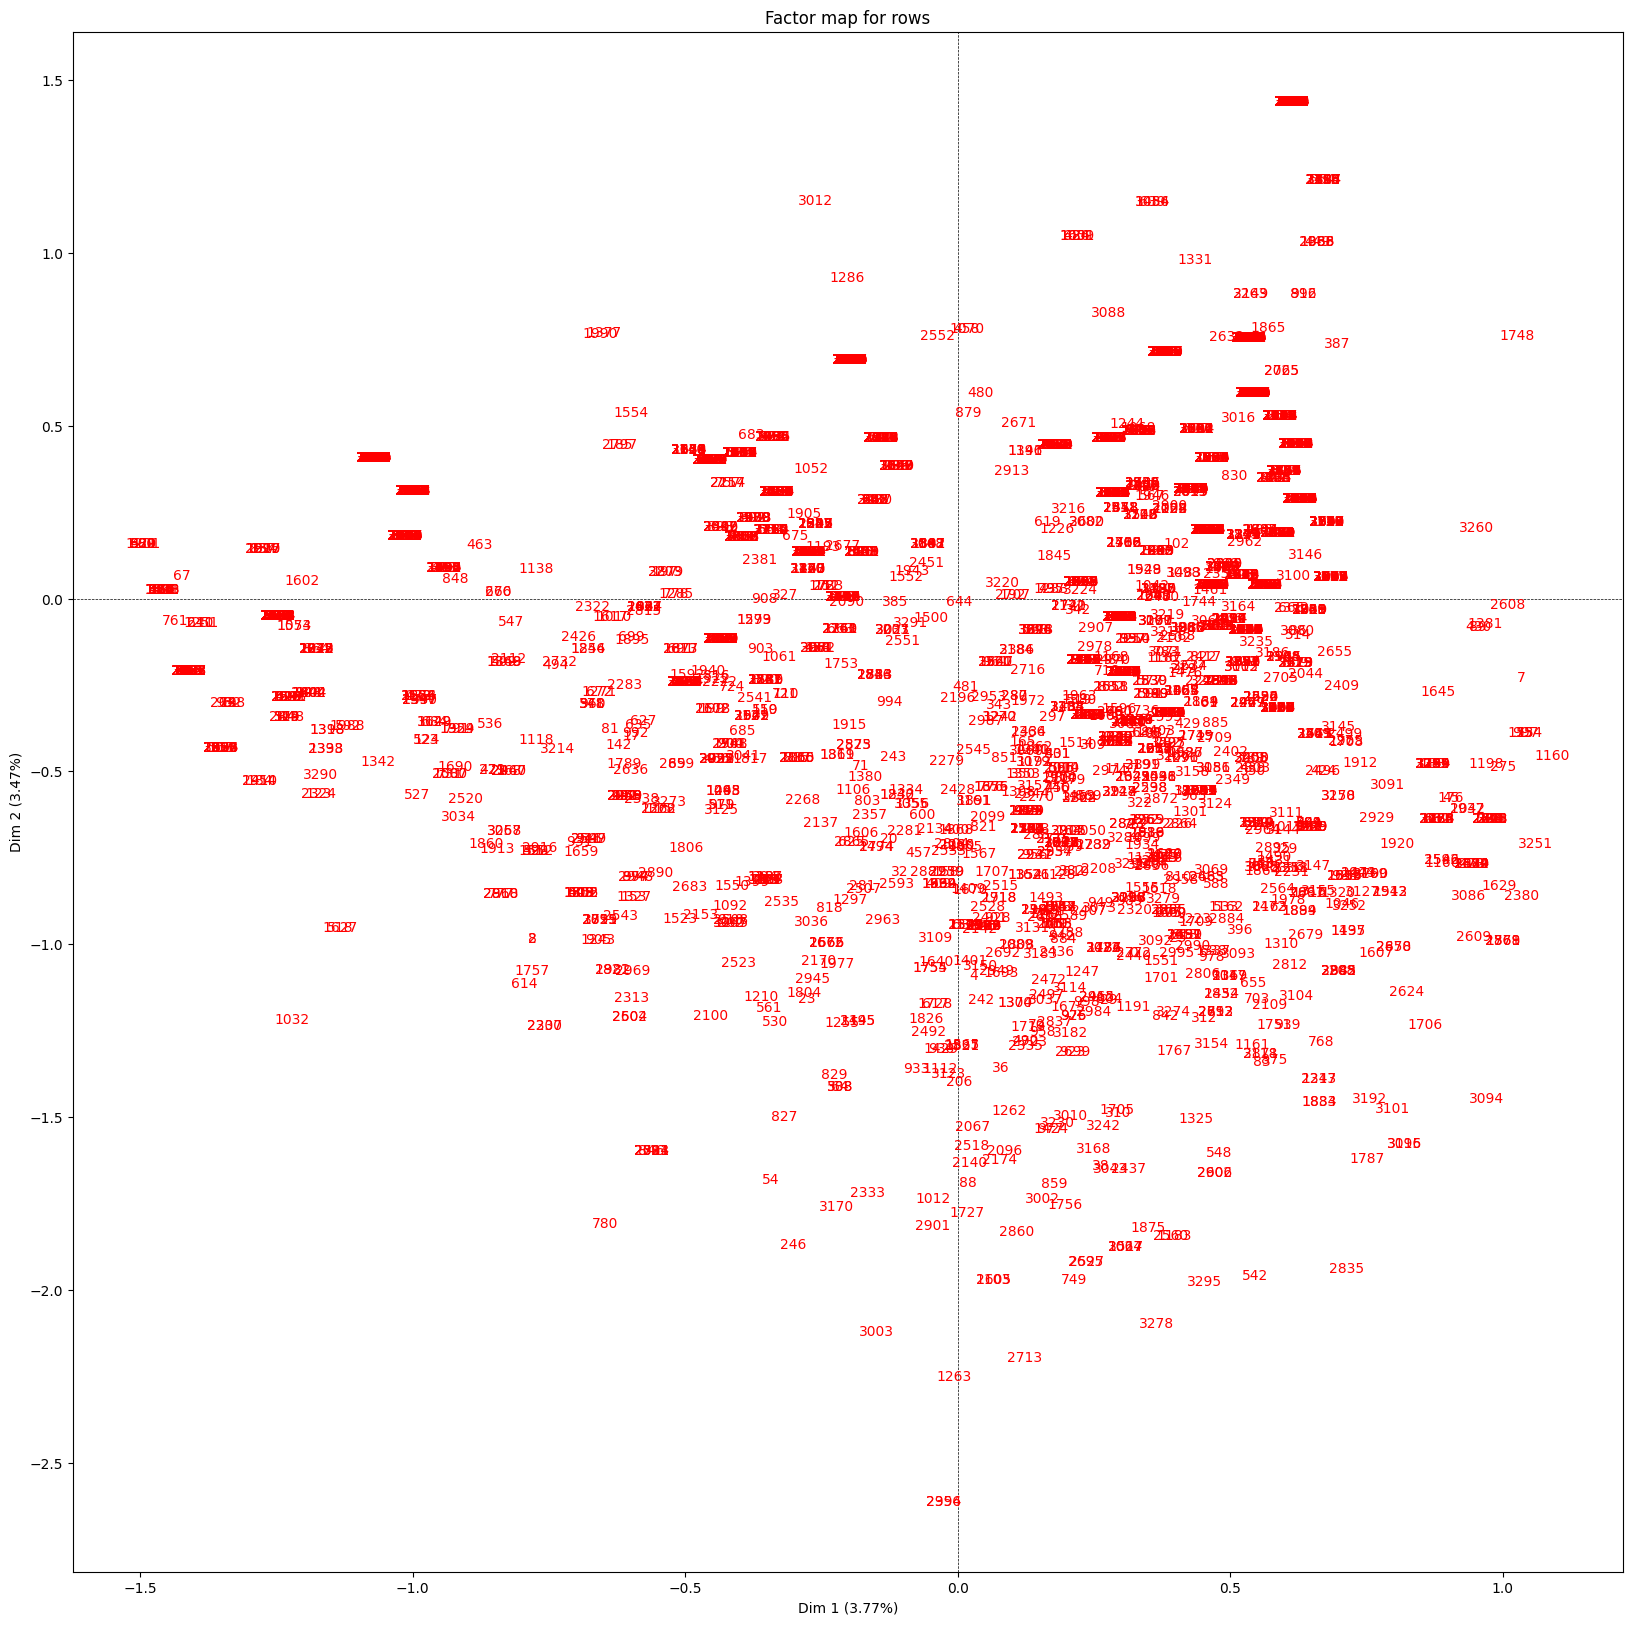

In [66]:
# Mapping des points lignes: individus
acm.mapping_row(num_x_axis=1, num_y_axis=2, figsize=(20,20))

## Représenter les individus

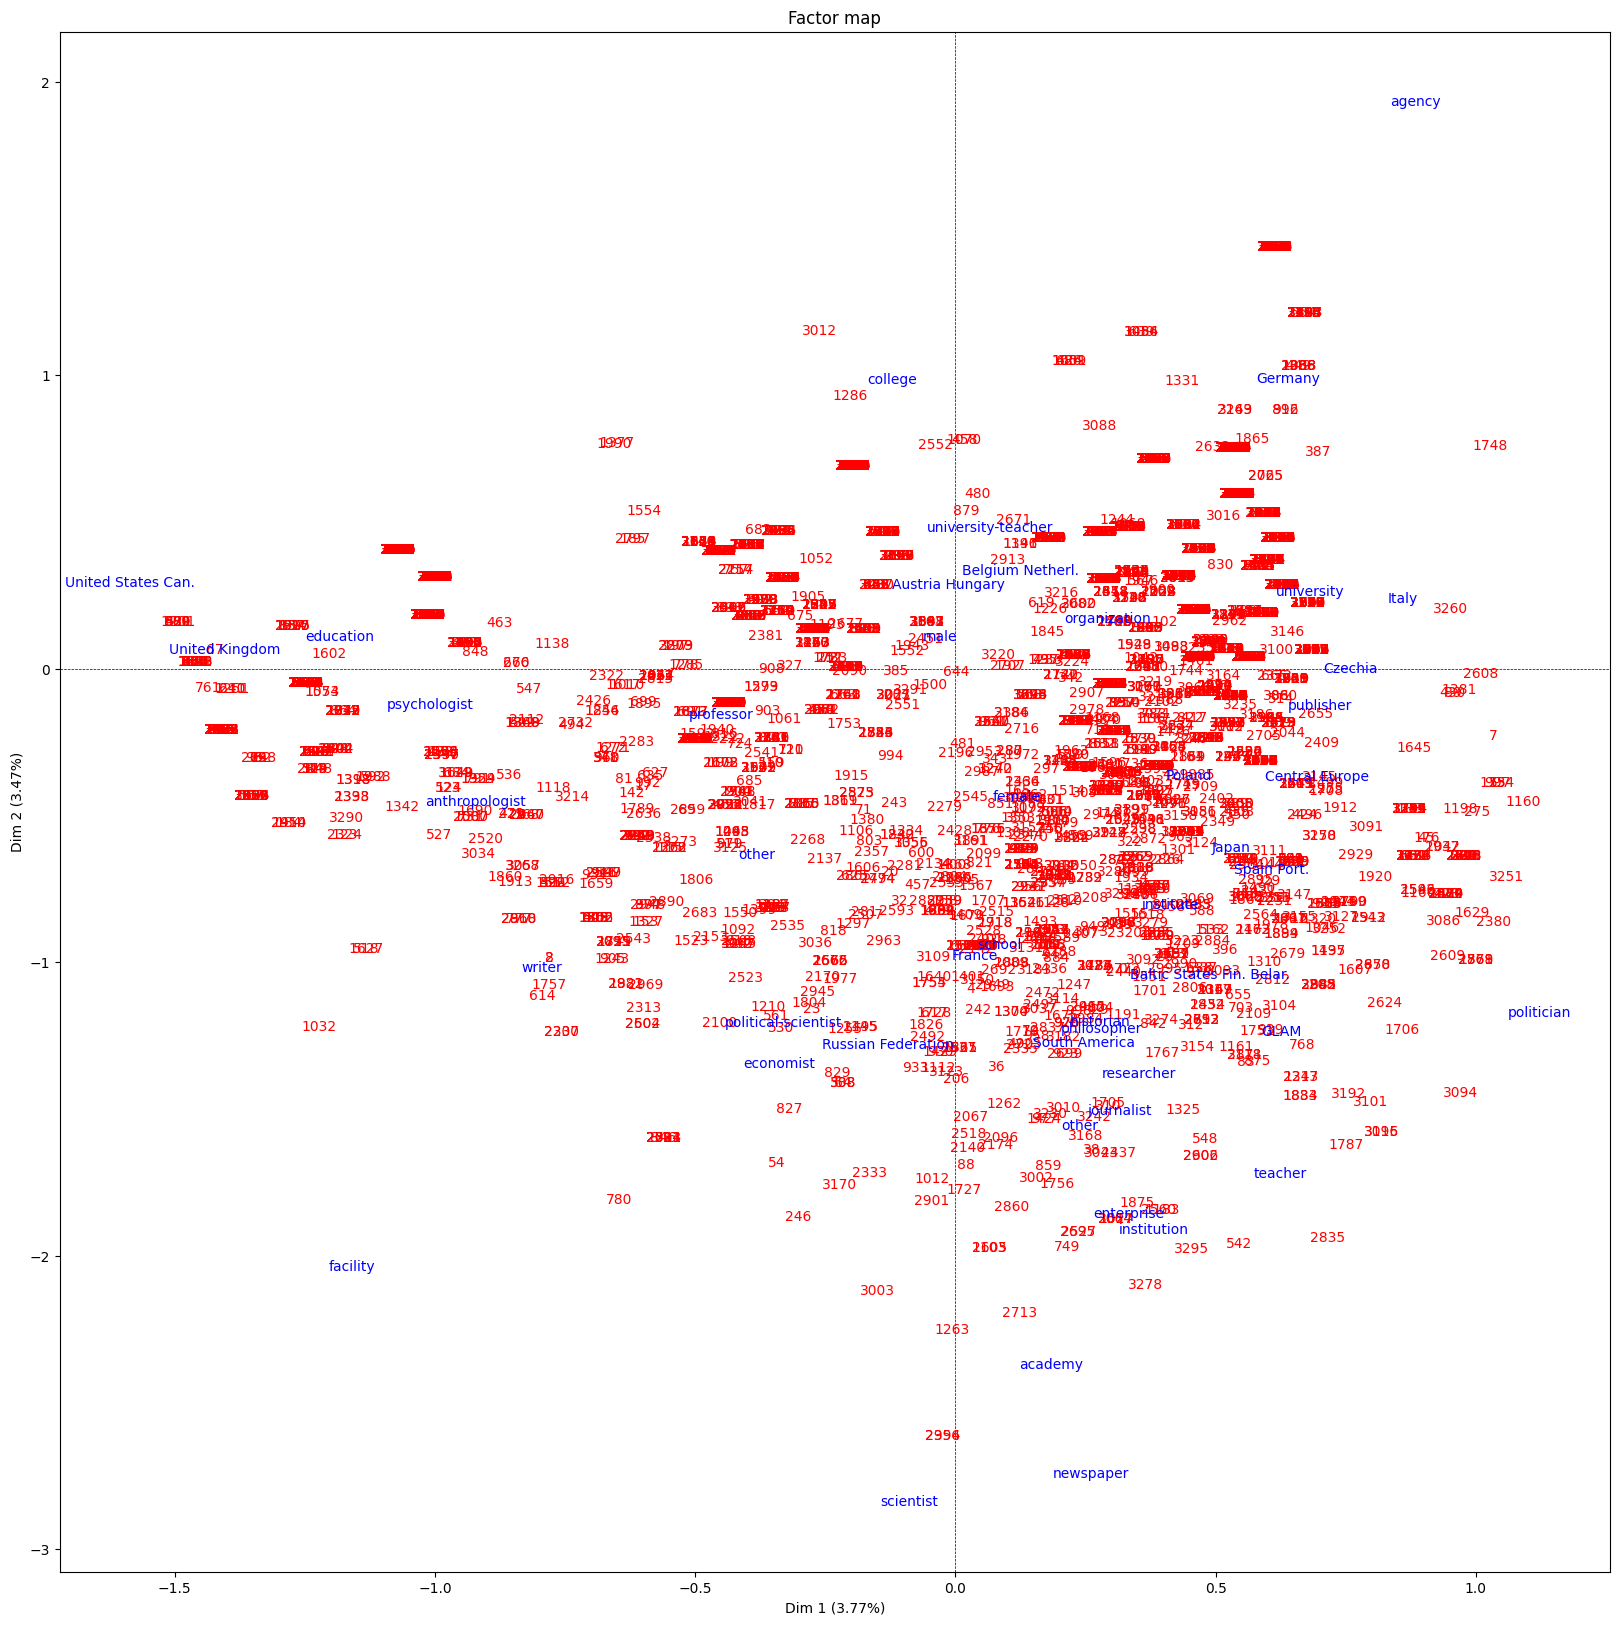

In [67]:
# Mapping simultané des points lignes et colonnes
# Les paramètres de la méthode mapping indiquent que ce sont les axes 1 et 2 qui sont ici représentés
acm.mapping(num_x_axis=1, num_y_axis=2, figsize=(20,20), )

In [68]:
### Inspect individuals
df_pm.loc[[709, 277, 1604, 2422, 1000]]

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_sec1,coded_employer
709,http://www.wikidata.org/entity/Q109557896,Jane Cassels Record,1915,female,Fort Gaines,POINT (-85.0483 31.6142),Northern America,United States,United States Can.,1946-1970,1011,university-teacher,education
277,http://www.wikidata.org/entity/Q599329,Edwin Sutherland,1883,male,Nebraska,POINT (-100 41.5),Northern America,United States,United States Can.,1921-1945,15182,other,education
1604,http://www.wikidata.org/entity/Q4863565,Barrie Thorne,1942,female,Utah,POINT (-111.5 39.5),Northern America,United States,United States Can.,1971-1995,13553,other,education
2422,http://www.wikidata.org/entity/Q112129103,Godfried Engbersen,1958,male,The Hague,POINT (4.31 52.08),Western Europe,Netherlands,Belgium Netherl.,1996-2020,1508,university-teacher,organization
1000,http://www.wikidata.org/entity/Q3610213,Alessandro Pizzorno,1924,male,Trieste,POINT (13.770278 45.650278),Southern Europe,Italy,Italy,1946-1970,12598,university-teacher,education


## Une possibilité d'interprétation: distance des individus par rapport au profil moyen

In [69]:
#Profil individu moyen
ind_moy = np.sum(X.values,axis=0)/(n*p)
print(ind_moy)

[0.05007576 0.19992424 0.01037879 0.00712121 0.00969697 0.00780303
 0.00643939 0.02       0.05590909 0.01636364 0.00454545 0.01977273
 0.0144697  0.00916667 0.01333333 0.01106061 0.04393939 0.00393939
 0.00371212 0.00636364 0.00280303 0.01856061 0.00477273 0.00507576
 0.00848485 0.00227273 0.00227273 0.00492424 0.00212121 0.00151515
 0.17007576 0.01310606 0.00166667 0.00060606 0.00795455 0.00121212
 0.08431818 0.00136364 0.00045455 0.01121212 0.00174242 0.00083333
 0.01583333 0.00439394 0.0725     0.00257576 0.04333333]


In [70]:
### Ajouter une colonne avec la distance chi-2 de chaque individu par rapport à l'individu moyen
# pour chaque individu: les individus plus éloignés sont plus rares
X['dist_org'] = X.apply(lambda x: round(np.sum(1/ind_moy*(x/p-ind_moy)**2),4), raw=True, axis=1)
X['dist_org']

0        14.3155
1         5.4418
2        23.9562
3         8.6551
4        80.1993
          ...   
3295    101.2974
3296      4.9419
3297     11.7617
3298     21.8450
3299      6.7030
Name: dist_org, Length: 3300, dtype: float64

count    3300.000000
mean       10.750005
std        14.044246
min         1.539200
25%         2.900100
50%         6.377300
75%        12.404100
max       158.684500
Name: dist_org, dtype: float64


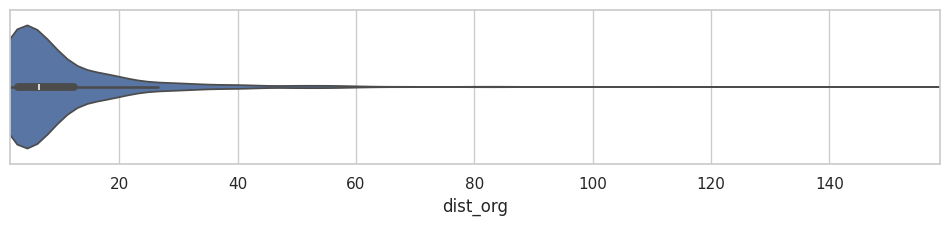

In [71]:

### Distribution des distances à l'individu moyen

sns.set_theme(style="whitegrid",rc={"figure.figsize":(12,2)} )


a = X['dist_org']

print(a.describe())

# ax = sns.boxplot(x=a)
ax = sns.violinplot(x=a)

### Noter que au delà des limites les valeurs sont coupées car postulées
ax.set_xlim(left=min(a), right=max(a))

plt.show()

In [72]:
### Individus proches du profil moyen
#  donc fréquents
i = X[(X.dist_org<8.5) & (X.dist_org>8.3)]
print(len(i))
df_pm.loc[i.index][30:35]

30


,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_sec1,coded_employer


In [73]:
### Individus moyennements distants du profil moyen
sel = X[(X.dist_org>8.3) & (X.dist_org <8.4)]   ### [X.dist_org<2.5] proches du prof. m.
print(len(sel))
df_pm.loc[sel.index][30:35]

16


,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_sec1,coded_employer


In [74]:
### Individus très distants du profil moyen
#  donc rares
seld = X[X.dist_org>200]
print(len(seld))
df_pm.loc[seld.index][-5:]

0


,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_sec1,coded_employer


## Add the activity periods as supplementary illustrative values

In [75]:
#isoler les variables supplémentaires (ou illustratives)
df_suppl = df_pm[['periodsActivity']]
print(df_suppl.columns)
df_suppl.head(2)

Index(['periodsActivity'], dtype='object')


,periodsActivity
0,1846-1870
1,1846-1870


In [76]:
info_lig = acm.row_topandas()
info_lig[:2]

,row_coord_dim1,row_coord_dim2,row_coord_dim3,row_coord_dim4,row_coord_dim5,row_coord_dim6,row_coord_dim7,row_coord_dim8,row_coord_dim9,row_coord_dim10,row_coord_dim11,row_coord_dim12,row_coord_dim13,row_coord_dim14,row_coord_dim15,row_coord_dim16,row_coord_dim17,row_coord_dim18,row_coord_dim19,row_coord_dim20,row_coord_dim21,row_coord_dim22,row_coord_dim23,row_coord_dim24,row_coord_dim25,row_coord_dim26,row_coord_dim27,row_coord_dim28,row_coord_dim29,row_coord_dim30,row_coord_dim31,row_coord_dim32,row_coord_dim33,row_coord_dim34,row_coord_dim35,row_coord_dim36,row_coord_dim37,row_coord_dim38,row_coord_dim39,row_coord_dim40,row_coord_dim41,row_coord_dim42,row_coord_dim43,row_contrib_dim1,row_contrib_dim2,row_contrib_dim3,row_contrib_dim4,row_contrib_dim5,row_contrib_dim6,row_contrib_dim7,row_contrib_dim8,row_contrib_dim9,row_contrib_dim10,row_contrib_dim11,row_contrib_dim12,row_contrib_dim13,row_contrib_dim14,row_contrib_dim15,row_contrib_dim16,row_contrib_dim17,row_contrib_dim18,row_contrib_dim19,row_contrib_dim20,row_contrib_dim21,row_contrib_dim22,row_contrib_dim23,row_contrib_dim24,row_contrib_dim25,row_contrib_dim26,row_contrib_dim27,row_contrib_dim28,row_contrib_dim29,row_contrib_dim30,row_contrib_dim31,row_contrib_dim32,row_contrib_dim33,row_contrib_dim34,row_contrib_dim35,row_contrib_dim36,row_contrib_dim37,row_contrib_dim38,row_contrib_dim39,row_contrib_dim40,row_contrib_dim41,row_contrib_dim42,row_contrib_dim43,row_cos2_dim1,row_cos2_dim2,row_cos2_dim3,row_cos2_dim4,row_cos2_dim5,row_cos2_dim6,row_cos2_dim7,row_cos2_dim8,row_cos2_dim9,row_cos2_dim10,row_cos2_dim11,row_cos2_dim12,row_cos2_dim13,row_cos2_dim14,row_cos2_dim15,row_cos2_dim16,row_cos2_dim17,row_cos2_dim18,row_cos2_dim19,row_cos2_dim20,row_cos2_dim21,row_cos2_dim22,row_cos2_dim23,row_cos2_dim24,row_cos2_dim25,row_cos2_dim26,row_cos2_dim27,row_cos2_dim28,row_cos2_dim29,row_cos2_dim30,row_cos2_dim31,row_cos2_dim32,row_cos2_dim33,row_cos2_dim34,row_cos2_dim35,row_cos2_dim36,row_cos2_dim37,row_cos2_dim38,row_cos2_dim39,row_cos2_dim40,row_cos2_dim41,row_cos2_dim42,row_cos2_dim43
0,0.321810,-1.022581,-0.785013,0.140707,-1.074306,0.622178,0.218297,-0.351893,0.792340,-0.286795,-0.478267,-0.847936,0.07480,0.557033,-1.340035,-0.237212,0.077885,-0.388375,0.625493,0.024977,-0.221155,0.059279,-0.043101,-0.785971,0.724187,-0.176830,-0.226381,-0.299485,-1.118905,0.768815,-0.335112,-0.743565,0.424433,-0.045586,-0.587211,-0.097589,1.169613,0.040578,-0.293049,0.180272,0.694029,-0.119813,-0.213497,0.007738,0.084972,0.051248,0.001832,0.111018,0.037334,0.004687,0.012502,0.065473,0.008833,0.025039,0.080187,0.000632,0.035156,0.205014,0.006523,0.000710,0.017753,0.046334,0.000076,0.005952,0.000429,0.000230,0.076631,0.065466,0.003969,0.006539,0.011597,0.166194,0.079219,0.015136,0.076153,0.025012,0.000305,0.051174,0.001428,0.214807,0.000263,0.014325,0.005507,0.088660,0.002862,0.012982,0.007234,0.073045,0.043047,0.001383,0.080621,0.027041,0.003329,0.008650,0.043855,0.005746,0.015978,0.050225,0.000391,0.021675,0.125437,0.003931,0.000424,0.010536,0.027330,0.000044,0.003417,0.000245,0.000130,0.043153,0.036635,0.002184,0.003580,0.006265,0.087454,0.041289,0.007845,0.038622,0.012584,0.000145,0.024087,0.000665,0.095560,0.000115,0.005999,0.002270,0.033647,0.001003,0.003184
1,0.231584,-0.175052,-1.067757,0.094863,-0.212837,0.020058,0.149075,-0.352756,0.614294,-0.058353,-0.061392,0.069646,-0.29739,-0.168415,-0.038741,-0.164320,-0.118906,-0.009484,-0.410800,-0.114263,0.200086,0.436420,0.213891,-0.349135,-0.242184,0.220927,-0.257514,-0.119507,-0.268533,0.388367,0.062303,-0.426951,0.845684,0.371805,-0.162217,-0.452314,-0.145238,0.477375,-0.359525,0.126756,0.666222,0.523949,-0.304964,0.004007,0.002490,0.094814,0.000833,0.004357,0.000039,0.002186,0.012563,0.039354,0.000366,0.000413,0.000541,0.009995,0.003214,0.000171,0.003130,0.001654,0.000011,0.019985,0.001582,0.004872,0.023243,0.005661,0.015121,0.007322,0.006196,0.008461,0.001847,0.009572,0.020215,0.000523,0.025107,0.099301,0.020290,0.003905,0.03

In [77]:
## We merge the two tables.
# Because they have the same order, the coordinates are added to the right individuals
df_supp_lignes = df_suppl.merge(info_lig, left_index=True, right_index=True)
df_supp_lignes.head(2)

,periodsActivity,row_coord_dim1,row_coord_dim2,row_coord_dim3,row_coord_dim4,row_coord_dim5,row_coord_dim6,row_coord_dim7,row_coord_dim8,row_coord_dim9,row_coord_dim10,row_coord_dim11,row_coord_dim12,row_coord_dim13,row_coord_dim14,row_coord_dim15,row_coord_dim16,row_coord_dim17,row_coord_dim18,row_coord_dim19,row_coord_dim20,row_coord_dim21,row_coord_dim22,row_coord_dim23,row_coord_dim24,row_coord_dim25,row_coord_dim26,row_coord_dim27,row_coord_dim28,row_coord_dim29,row_coord_dim30,row_coord_dim31,row_coord_dim32,row_coord_dim33,row_coord_dim34,row_coord_dim35,row_coord_dim36,row_coord_dim37,row_coord_dim38,row_coord_dim39,row_coord_dim40,row_coord_dim41,row_coord_dim42,row_coord_dim43,row_contrib_dim1,row_contrib_dim2,row_contrib_dim3,row_contrib_dim4,row_contrib_dim5,row_contrib_dim6,row_contrib_dim7,row_contrib_dim8,row_contrib_dim9,row_contrib_dim10,row_contrib_dim11,row_contrib_dim12,row_contrib_dim13,row_contrib_dim14,row_contrib_dim15,row_contrib_dim16,row_contrib_dim17,row_contrib_dim18,row_contrib_dim19,row_contrib_dim20,row_contrib_dim21,row_contrib_dim22,row_contrib_dim23,row_contrib_dim24,row_contrib_dim25,row_contrib_dim26,row_contrib_dim27,row_contrib_dim28,row_contrib_dim29,row_contrib_dim30,row_contrib_dim31,row_contrib_dim32,row_contrib_dim33,row_contrib_dim34,row_contrib_dim35,row_contrib_dim36,row_contrib_dim37,row_contrib_dim38,row_contrib_dim39,row_contrib_dim40,row_contrib_dim41,row_contrib_dim42,row_contrib_dim43,row_cos2_dim1,row_cos2_dim2,row_cos2_dim3,row_cos2_dim4,row_cos2_dim5,row_cos2_dim6,row_cos2_dim7,row_cos2_dim8,row_cos2_dim9,row_cos2_dim10,row_cos2_dim11,row_cos2_dim12,row_cos2_dim13,row_cos2_dim14,row_cos2_dim15,row_cos2_dim16,row_cos2_dim17,row_cos2_dim18,row_cos2_dim19,row_cos2_dim20,row_cos2_dim21,row_cos2_dim22,row_cos2_dim23,row_cos2_dim24,row_cos2_dim25,row_cos2_dim26,row_cos2_dim27,row_cos2_dim28,row_cos2_dim29,row_cos2_dim30,row_cos2_dim31,row_cos2_dim32,row_cos2_dim33,row_cos2_dim34,row_cos2_dim35,row_cos2_dim36,row_cos2_dim37,row_cos2_dim38,row_cos2_dim39,row_cos2_dim40,row_cos2_dim41,row_cos2_dim42,row_cos2_dim43
0,1846-1870,0.321810,-1.022581,-0.785013,0.140707,-1.074306,0.622178,0.218297,-0.351893,0.792340,-0.286795,-0.478267,-0.847936,0.07480,0.557033,-1.340035,-0.237212,0.077885,-0.388375,0.625493,0.024977,-0.221155,0.059279,-0.043101,-0.785971,0.724187,-0.176830,-0.226381,-0.299485,-1.118905,0.768815,-0.335112,-0.743565,0.424433,-0.045586,-0.587211,-0.097589,1.169613,0.040578,-0.293049,0.180272,0.694029,-0.119813,-0.213497,0.007738,0.084972,0.051248,0.001832,0.111018,0.037334,0.004687,0.012502,0.065473,0.008833,0.025039,0.080187,0.000632,0.035156,0.205014,0.006523,0.000710,0.017753,0.046334,0.000076,0.005952,0.000429,0.000230,0.076631,0.065466,0.003969,0.006539,0.011597,0.166194,0.079219,0.015136,0.076153,0.025012,0.000305,0.051174,0.001428,0.214807,0.000263,0.014325,0.005507,0.088660,0.002862,0.012982,0.007234,0.073045,0.043047,0.001383,0.080621,0.027041,0.003329,0.008650,0.043855,0.005746,0.015978,0.050225,0.000391,0.021675,0.125437,0.003931,0.000424,0.010536,0.027330,0.000044,0.003417,0.000245,0.000130,0.043153,0.036635,0.002184,0.003580,0.006265,0.087454,0.041289,0.007845,0.038622,0.012584,0.000145,0.024087,0.000665,0.095560,0.000115,0.005999,0.002270,0.033647,0.001003,0.003184
1,1846-1870,0.231584,-0.175052,-1.067757,0.094863,-0.212837,0.020058,0.149075,-0.352756,0.614294,-0.058353,-0.061392,0.069646,-0.29739,-0.168415,-0.038741,-0.164320,-0.118906,-0.009484,-0.410800,-0.114263,0.200086,0.436420,0.213891,-0.349135,-0.242184,0.220927,-0.257514,-0.119507,-0.268533,0.388367,0.062303,-0.426951,0.845684,0.371805,-0.162217,-0.452314,-0.145238,0.477375,-0.359525,0.126756,0.666222,0.523949,-0.304964,0.004007,0.002490,0.094814,0.000833,0.004357,0.000039,0.002186,0.012563,0.039354,0.000366,0.000413,0.000541,0.009995,0.003214,0.000171,0.003130,0.001654,0.000011,0.019985,0.001582,0.004872,0.023243,0.005661,0.015121,0.007322,0.006196,0.008461,0.001847,0.009572,0.020215,0.000523,0.02

### Plot dim1-dim2

In [78]:
#positionnement d'individus
coord = df_supp_lignes[['periodsActivity','row_coord_dim1', 'row_coord_dim2']].copy()
print(len(coord))
coord.head(2)


3300


,periodsActivity,row_coord_dim1,row_coord_dim2
0,1846-1870,0.321810,-1.022581
1,1846-1870,0.231584,-0.175052


In [79]:

#moyennes conditionnelles - Livre, page 341
coord_fact = pd.pivot_table(data=coord,values=['row_coord_dim1', 'row_coord_dim2'],index='periodsActivity',aggfunc='mean')
coord_fact


,row_coord_dim1,row_coord_dim2
periodsActivity,,
1846-1870,-0.198145,-0.186902
1871-1895,0.073083,-0.212120
1896-1920,-0.271869,-0.030576
1921-1945,-0.111251,0.133658
1946-1970,-0.251556,0.061568
1971-1995,-0.001238,0.041269
1996-2020,0.154635,-0.082255


In [80]:

#corrigés par la racine carrée des valeurs propres
# computed barycenters on 2 dimensions (row_coord_dim1 and row_coord_dim2): [:2]
coord_fact = coord_fact/np.sqrt(acm.eig_[0][:2])
print(coord_fact)

                 row_coord_dim1  row_coord_dim2
periodsActivity                                
1846-1870             -0.311138       -0.306063
1871-1895              0.114759       -0.347359
1896-1920             -0.426904       -0.050069
1921-1945             -0.174693        0.218873
1946-1970             -0.395006        0.100821
1971-1995             -0.001944        0.067581
1996-2020              0.242816       -0.134698


In [81]:
MCA.mapping_col = cal.custom_mapping_col

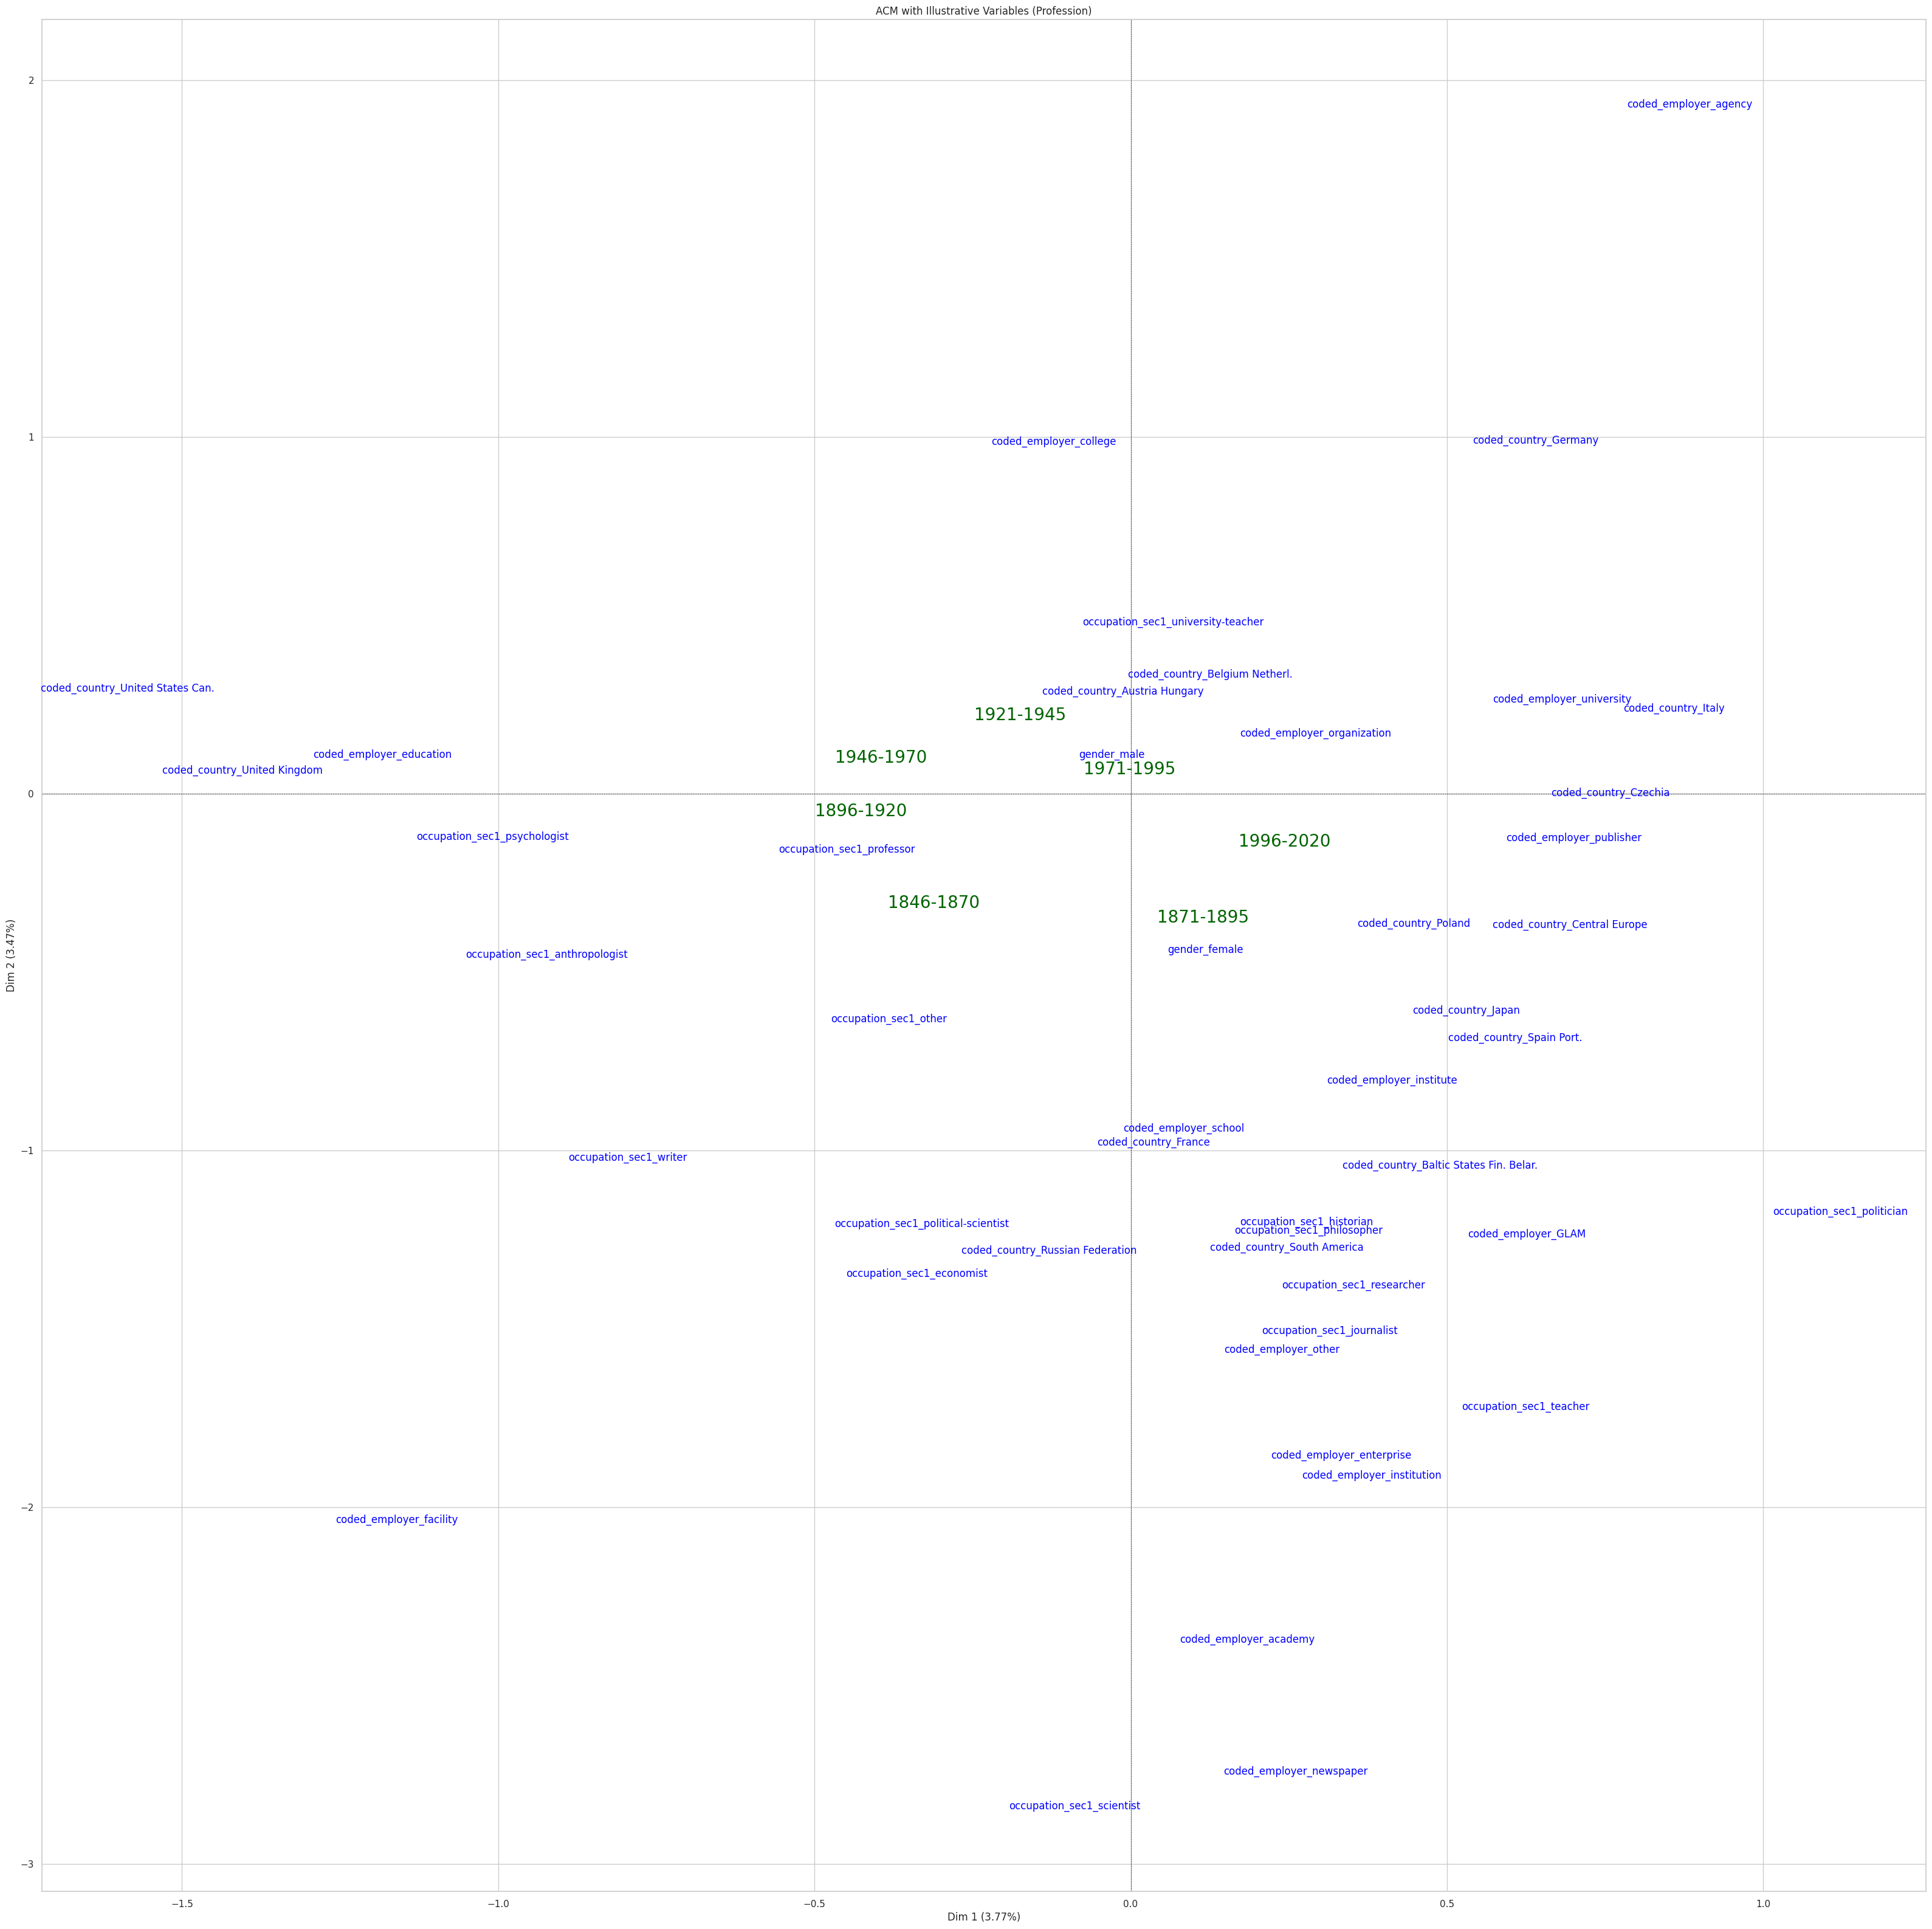

In [82]:


# Create your own figure and axes
fig, ax = plt.subplots(figsize=(40, 40))

# Plot ACM on ax
acm.mapping_col(num_x_axis=1, num_y_axis=2, ax=ax, short_labels=False)

# Add your additional layer

# Add illustrative variable modalities (e.g., Profession)
ax = plt.gca()  # Get current axis
for i in range(coord_fact.shape[0]):
    ax.text(coord_fact.iloc[i, 0], coord_fact.iloc[i, 1], coord_fact.index[i],
            color="darkgreen", fontsize=20, ha='center', va='center')

plt.title("ACM with Illustrative Variables (Profession)")
plt.show()


## Prepare file for cluster analysis

Given that the interpretation of the MCA is quite difficult, given the sparse nature of the variables, we will test the [K-means clustering method](da5-MCA-clusters.ipynb) on the results of the MCA in order to detect significant profiles.

We therefore export here the coded and prepared data to a [dedicated CSV file](da_data/da5-MCA-clusters.csv).

In [83]:
df_pm.head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_sec1,coded_employer
0,http://www.wikidata.org/entity/Q2993155,Konstantin Kavelin,1818,male,Saint Petersburg,POINT (30.316667 59.95),European Russia,Russian Federation,Russian Federation,1846-1870,11704,historian,publisher
1,http://www.wikidata.org/entity/Q555693,Timofey Granovsky,1813,male,Oryol,POINT (36.069444 52.968611),European Russia,Russian Federation,Russian Federation,1846-1870,14217,university-teacher,university
2,http://www.wikidata.org/entity/Q144535,Herbert Spencer,1820,male,Derby,POINT (-1.476667 52.921667),Northern Europe,United Kingdom,United Kingdom,1846-1870,8360,writer,other


In [84]:
file_address='da_data/da5-MCA-clusters.csv'
df_pm.to_csv(file_address, index=False)

## Split the generations and analyse significant ones

In [98]:
activity_period='1846-1870'
df_pm[df_pm.periodsActivity==activity_period].head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_sec1,coded_employer
0,http://www.wikidata.org/entity/Q2993155,Konstantin Kavelin,1818,male,Saint Petersburg,POINT (30.316667 59.95),European Russia,Russian Federation,Russian Federation,1846-1870,11704,historian,publisher
1,http://www.wikidata.org/entity/Q555693,Timofey Granovsky,1813,male,Oryol,POINT (36.069444 52.968611),European Russia,Russian Federation,Russian Federation,1846-1870,14217,university-teacher,university
2,http://www.wikidata.org/entity/Q144535,Herbert Spencer,1820,male,Derby,POINT (-1.476667 52.921667),Northern Europe,United Kingdom,United Kingdom,1846-1870,8360,writer,other


## MCA

In [99]:
data_cat = df_pm[df_pm.periodsActivity==activity_period][['gender', 'coded_country', 'occupation_sec1', 'coded_employer']]
data_cat.head(3)


,gender,coded_country,occupation_sec1,coded_employer
0,male,Russian Federation,historian,publisher
1,male,Russian Federation,university-teacher,university
2,male,United Kingdom,writer,other


In [100]:
DActives=data_cat

In [101]:
acm = MCA(row_labels=DActives.index,var_labels=DActives.columns)
acm.fit(DActives.values)

/home/my_venvs/data_analysis/lib/python3.12/site-packages/fanalysis/base.py:228: RuntimeWarning: invalid value encountered in divide
  R = (1.0 / np.sqrt(self.n_)) * (X - E) / np.sqrt(E)


LinAlgError: SVD did not converge

In [102]:
eig = pd.DataFrame(acm.eig_).transpose()
eig.columns=['contribution','freq','freq_cumulee']

print('Number of factors (approximation tables):', len(eig), '\n')
print(eig.head(), eig.tail())


AttributeError: 'MCA' object has no attribute 'eig_'

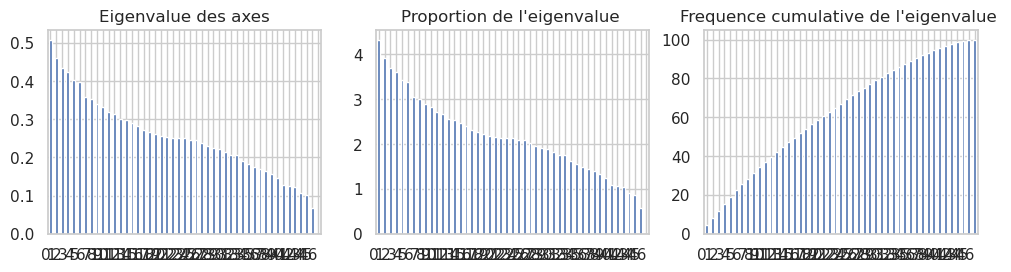

In [169]:

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12,3))

eig.iloc[:,0].plot(kind='bar', ax=axes[0], title='Eigenvalue des axes')
eig.iloc[:,1].plot(kind='bar', ax=axes[1], title="Proportion de l'eigenvalue ")
eig.iloc[:,2].plot(kind='bar', ax=axes[2], title="Frequence cumulative de l'eigenvalue ")
# Met les valeurs xticks en vertical
fig.autofmt_xdate(rotation=0)
plt.show()

<Axes: title={'center': 'Factor map for columns'}, xlabel='Dim 1 (4.33%)', ylabel='Dim 1 (4.33%)'>

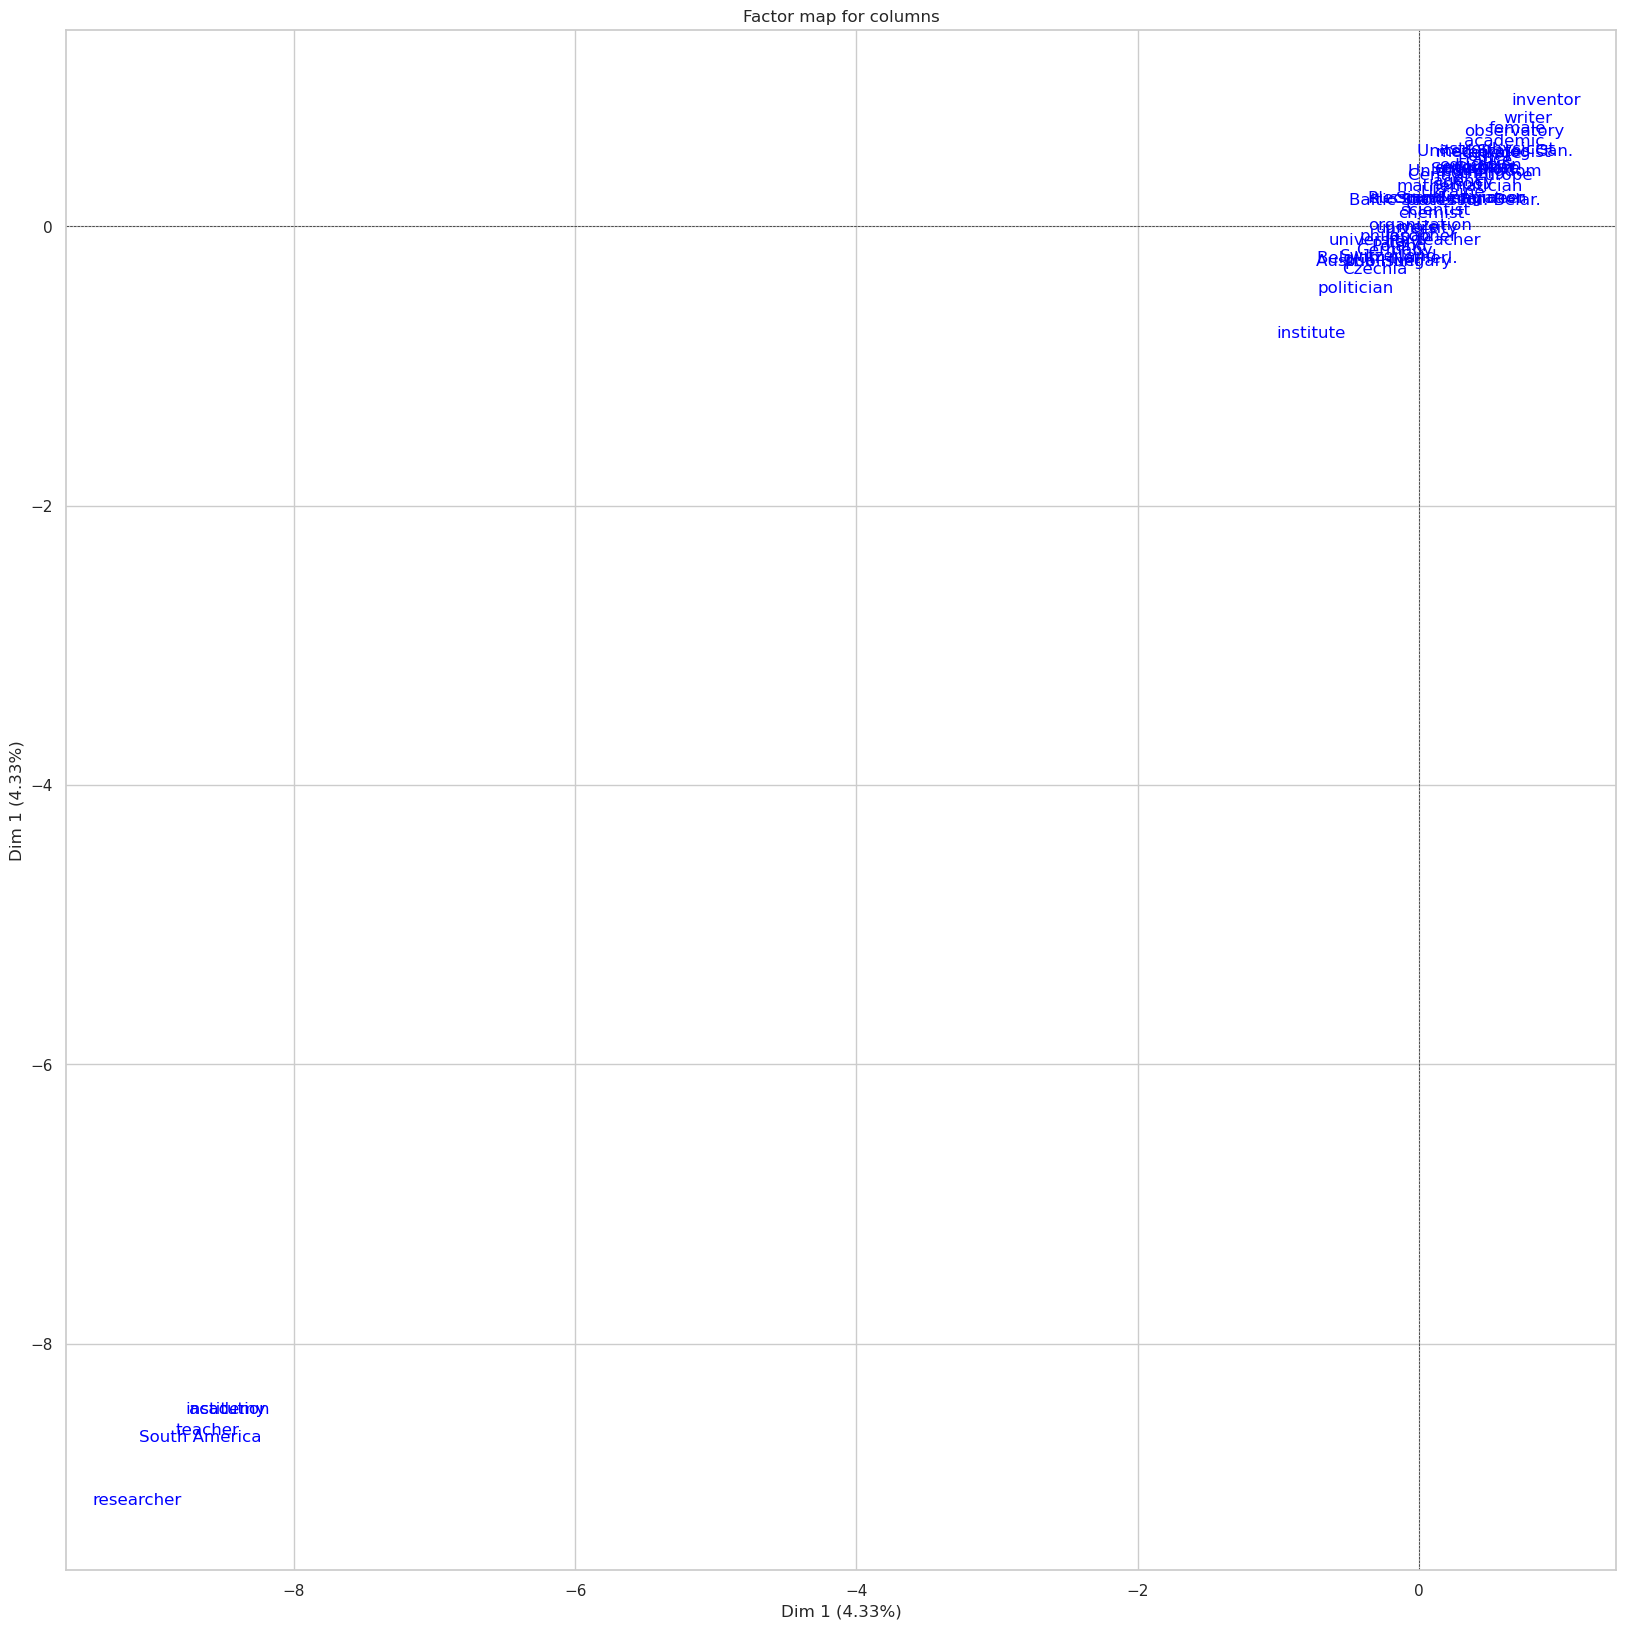

In [173]:
# Mapping des points colonnes
acm.mapping_col(num_x_axis=1, num_y_axis=1, figsize=(20,20))

## Représenter les individus

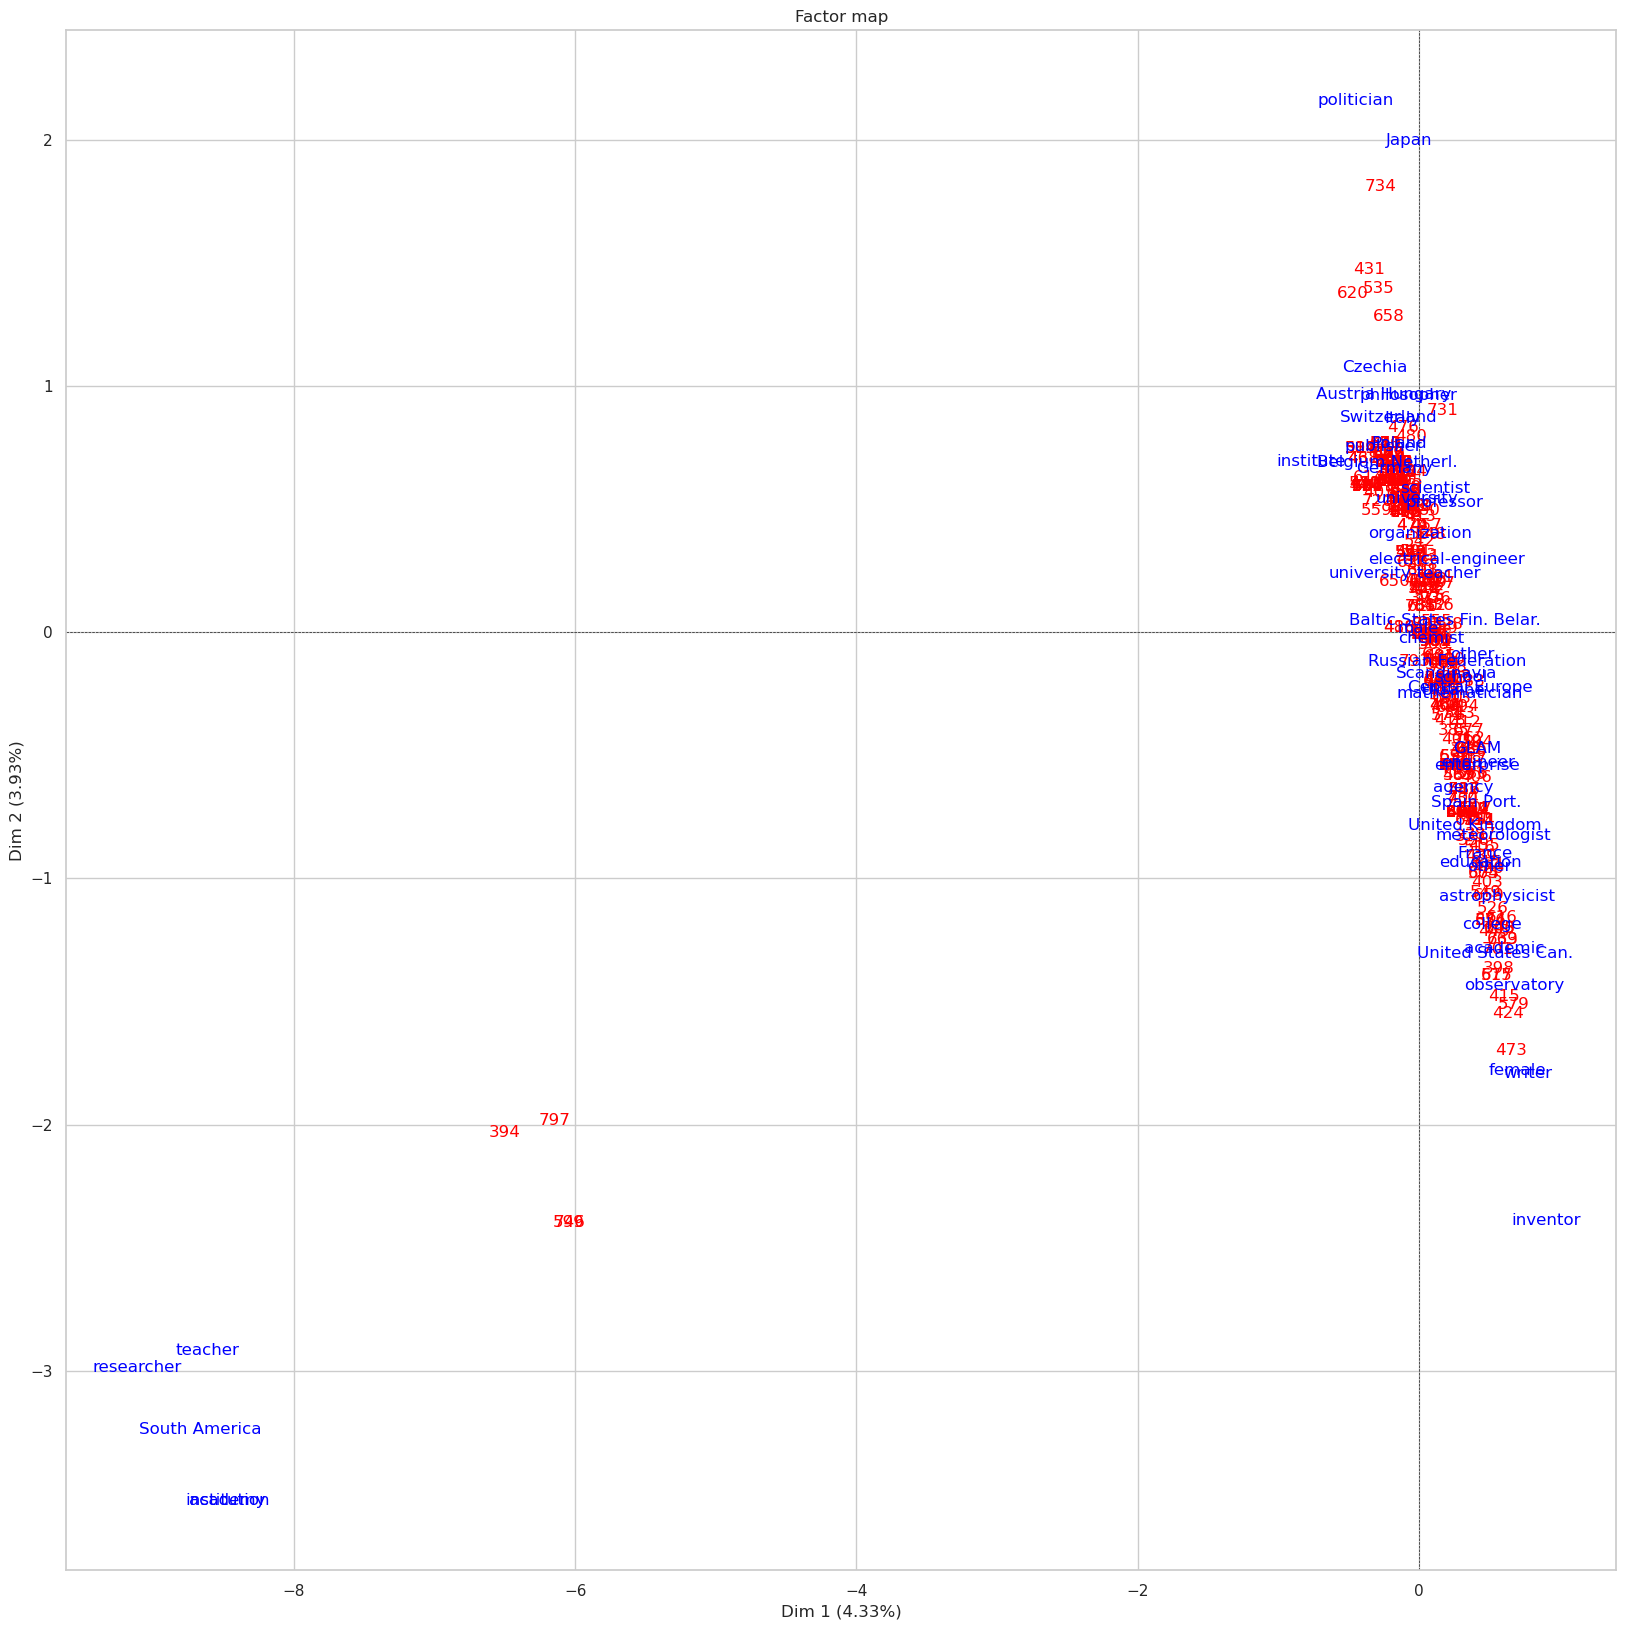

In [174]:
# Mapping simultané des points lignes et colonnes
# Les paramètres de la méthode mapping indiquent que ce sont les axes 1 et 2 qui sont ici représentés
acm.mapping(num_x_axis=1, num_y_axis=2, figsize=(20,20), )

In [175]:
### Inspect individuals
df_pm.loc[[394, 797, 424, 473]]

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_main,occupation_sec1,coded_employer
394,http://www.wikidata.org/entity/Q10324424,Manuel Pereira Reis,1837,male,Salvador,POINT (-38.492778 -12.983056),South America,Brazil,South America,1876-1900,763,astronomer,researcher,institute
797,http://www.wikidata.org/entity/Q24262108,Arturo Salazar,1855,male,Andacollo,POINT (-71.083333 -30.216667),South America,Chile,South America,1876-1900,15607,physicist,teacher,publisher
424,http://www.wikidata.org/entity/Q250936,Gaston Planté,1834,male,Orthez,POINT (-0.770833 43.488055),Western Europe,France,France,1876-1900,15879,physicist,inventor,education
473,http://www.wikidata.org/entity/Q3614641,Amos Dolbear,1837,male,Norwich,POINT (-72.0875 41.550278),Northern America,United States,United States Can.,1876-1900,18677,physicist,inventor,education
